# LTO-Only Direct Training — Batt10
**Split:** 70% train | 10% val | 20% test


## Model Designs & Multi‑Seed Results

**Input**: 60 time steps of `[U_DC_Batt, I_DC_Batt, V_avg_2h, I_avg_2h]` → predict next‑minute SOC.

### CNN‑only (residual)
Input → Conv1D(32) → Conv1D(64) + shortcut → Flatten → Dense(64) → Output


### LSTM‑only (self‑attention)
Input → LSTM(128) → Attention → Context → Dense(64) → Output


### Dual‑branch (gated)
Input
/
CNN branch LSTM branch
(Conv layers) (LSTM)
\ /
Concatenate
│
Gate (sigmoid)
│
Weighted sum → Dense(64) → Output


### Training
- 70% train, 10% val, 20% test (chronological)
- MAE loss, Adam (lr=1e‑3), batch=256, shuffle=True
- EarlyStopping (15), ReduceLR (6)

### Multi‑seed results (5 seeds)
| Model       | MAE (%)       | RMSE (%)      |
|-------------|---------------|---------------|
| CNN‑only    | 1.3365 ± 0.1326 | 1.7779 ± 0.1122 |
| LSTM‑only   | 1.3400 ± 0.0792 | 1.7781 ± 0.0517 |
| **Dual‑branch** | **1.2030 ± 0.0347** | **1.7158 ± 0.0411** |

**Conclusion:** Dual‑branch achieves ~10% lower MAE and is far more consistent (smaller std).

In [1]:
# ─── Colab Setup ──────────────────────────────────────────────────────────────
import os, zipfile, tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU available: {gpus}')
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print('⚠️  No GPU — Runtime > Change runtime type > GPU')

ZIP_PATH = '/content/drive/MyDrive/M5BAT.zip'
EXTR_DIR = '/content/data/M5BAT'

if not os.path.exists(EXTR_DIR):
    os.makedirs('/content/data', exist_ok=True)
    print('Extracting M5BAT.zip ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTR_DIR)
    print('✅ Done.')
else:
    print('✅ Already extracted.')

Mounted at /content/drive
✅ GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Extracting M5BAT.zip ...
✅ Done.


In [24]:
# ─── Cell 1 — Imports & Config ────────────────────────────────────────────────
import os, json, pickle, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, LSTM, Dense, Dropout,
    BatchNormalization, Flatten, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 12345
#SEED = 42
#SEED = 777
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Force TensorFlow deterministic ops (GPU only)
tf.config.experimental.enable_op_determinism()
# ── Directories ───────────────────────────────────────────────────────────────
M5BAT_DATA_DIR = '/content/data/M5BAT/M5BAT'
PROC_DIR       = '/content/processed'
SAVE_DIR       = '/content/saved'
FIG_DIR        = '/content/figures'
for d in [PROC_DIR, SAVE_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Features ──────────────────────────────────────────────────────
RAW_COLS  = ['U_DC_Batt', 'I_DC_Batt']
AVG_COLS  = ['V_avg_2h', 'I_avg_2h']
FEAT_COLS = RAW_COLS + AVG_COLS
N_FEAT    = len(FEAT_COLS)   # 4

# ── Window & resampling ───────────────────────────────────────────
SEQ_LEN  = 60
HOP      = 1
RESAMPLE = '1min'
AVG_WIN  = 120

# ── Architecture  ──────────────────────────────────────────────────
CNN_F1      = 32
CNN_F2      = 64
CNN_KERNEL  = 3
LSTM_UNITS  = 128
BRANCH_DIM  = 64
DENSE_UNITS = 64
DROPOUT     = 0.25

# ── Training ──────────────────────────────────────────────────────
LR_BASE    = 1e-3
BATCH_SIZE = 256
EPOCHS     = 100
ES_PAT     = 15
RLR_PAT    = 6

# ── Split ratios: 70% train | 10% val | 20% test ─────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.10
# TEST_RATIO  = 0.20  (remainder)

print('✅ Imports OK.')
print(f'TF {tf.__version__} | Features: {FEAT_COLS} | Window: {SEQ_LEN} min')
print(f'Split: {int(TRAIN_RATIO*100)}% train / {int(VAL_RATIO*100)}% val / 20% test')

✅ Imports OK.
TF 2.20.0 | Features: ['U_DC_Batt', 'I_DC_Batt', 'V_avg_2h', 'I_avg_2h'] | Window: 60 min
Split: 70% train / 10% val / 20% test


In [25]:
# ─── Cell 2 — Data Loading ────────────────────────────────────────────────────

def load_m5bat(filepath):
    bname = os.path.basename(filepath).replace('.csv', '')
    df = pd.read_csv(
        filepath, sep=';',
        parse_dates=['DateAndTime'],
        infer_datetime_format=True,
        low_memory=False
    ).set_index('DateAndTime').sort_index()

    df['SOC'] = df['SOC'] / 10.0
    if 'interpolated' in df.columns:
        df = df[df['interpolated'] == 0]

    df = df[RAW_COLS + ['SOC']]
    df_min = df.resample(RESAMPLE).agg(
        {**{c: 'mean' for c in RAW_COLS}, 'SOC': 'last'}
    ).dropna()

    df_min['V_avg_2h'] = df_min['U_DC_Batt'].rolling(AVG_WIN, min_periods=30).mean()
    df_min['I_avg_2h'] = df_min['I_DC_Batt'].rolling(AVG_WIN, min_periods=30).mean()
    df_min = df_min.dropna()

    print(f'  {bname}: {len(df_min):,} rows | '
          f'SOC [{df_min.SOC.min():.1f}\u2013{df_min.SOC.max():.1f}%] | '
          f'{df_min.index[0].date()} \u2192 {df_min.index[-1].date()}')
    return df_min


# ── Check file ────────────────────────────────────────────────────────────────
p = os.path.join(M5BAT_DATA_DIR, 'Batt10.csv')
status = f'{os.path.getsize(p)/1e6:.1f} MB' if os.path.exists(p) else '\u274c MISSING'
print(f'  Batt10.csv   {status}')

  Batt10.csv   143.7 MB


In [26]:
# ─── Cell 3 — Load, Split, Scale, Extract Windows (LTO ONLY) ─────────────────

def extract_windows(df, scaler_feat, scaler_soc):
    df_n = df.copy()
    df_n[FEAT_COLS] = scaler_feat.transform(df[FEAT_COLS].values)
    df_n['SOC']     = scaler_soc.transform(df[['SOC']].values)
    feat = df_n[FEAT_COLS].values.astype(np.float32)
    soc  = df_n['SOC'].values.astype(np.float32)
    X_list, Y_list = [], []
    for i in range(0, len(feat) - SEQ_LEN, HOP):
        X_list.append(feat[i:i+SEQ_LEN])
        Y_list.append(soc[i+SEQ_LEN])
    X = np.stack(X_list).astype(np.float32)
    Y = np.array(Y_list, dtype=np.float32).reshape(-1, 1)
    return X, Y


# Load Batt10 only
print('Loading Batt10 (LTO only)...')
df_batt10 = load_m5bat(os.path.join(M5BAT_DATA_DIR, 'Batt10.csv'))

# Chronological split: 70% train | 10% val | 20% test
n        = len(df_batt10)
n_train  = int(n * TRAIN_RATIO)
n_val    = int(n * VAL_RATIO)
n_test   = n - n_train - n_val

df_train = df_batt10.iloc[:n_train]
df_val   = df_batt10.iloc[n_train : n_train + n_val]
df_test  = df_batt10.iloc[n_train + n_val:]

print(f'\nBatt10 split:')
print(f'  Total : {n:,} rows')
print(f'  Train : {len(df_train):,}  '
      f'({df_train.index[0].date()} \u2192 {df_train.index[-1].date()})')
print(f'  Val   : {len(df_val):,}  '
      f'({df_val.index[0].date()} \u2192 {df_val.index[-1].date()})')
print(f'  Test  : {len(df_test):,}  '
      f'({df_test.index[0].date()} \u2192 {df_test.index[-1].date()})')

# Fit scalers on train portion ONLY
scaler_feat = MinMaxScaler((0, 1)).fit(df_train[FEAT_COLS].values)
scaler_soc  = MinMaxScaler((0, 1)).fit(df_train[['SOC']].values)

print(f'\nScalers fitted on train portion:')
print(f'  SOC range : [{scaler_soc.data_min_[0]:.1f}, {scaler_soc.data_max_[0]:.1f}] %')

# Extract sliding windows
print('\nExtracting sliding windows...')
trainX, trainY = extract_windows(df_train, scaler_feat, scaler_soc)
valX,   valY   = extract_windows(df_val,   scaler_feat, scaler_soc)
testX,  testY  = extract_windows(df_test,  scaler_feat, scaler_soc)

print(f'\nDataset summary:')
print(f'  Train : {trainX.shape}  (Batt10 70%)')
print(f'  Val   : {valX.shape}   (Batt10 10%)')
print(f'  Test  : {testX.shape}  (Batt10 20%)')

with open(os.path.join(PROC_DIR, 'scalers_lto_only.pkl'), 'wb') as f:
    pickle.dump({'feat': scaler_feat, 'soc': scaler_soc}, f)
print('\n\u2713 Scalers saved.')

Loading Batt10 (LTO only)...
  Batt10: 43,171 rows | SOC [19.9–71.1%] | 2023-04-01 → 2023-04-30

Batt10 split:
  Total : 43,171 rows
  Train : 30,219  (2023-04-01 → 2023-04-22)
  Val   : 4,317  (2023-04-22 → 2023-04-25)
  Test  : 8,635  (2023-04-25 → 2023-04-30)

Scalers fitted on train portion:
  SOC range : [19.9, 70.6] %

Extracting sliding windows...

Dataset summary:
  Train : (30159, 60, 4)  (Batt10 70%)
  Val   : (4257, 60, 4)   (Batt10 10%)
  Test  : (8575, 60, 4)  (Batt10 20%)

✓ Scalers saved.


In [27]:
# ─── Cell 4 — Shared Utilities ───────────────────────────────────────────────

def make_callbacks(monitor='val_loss', es_pat=ES_PAT,
                   rlr_pat=RLR_PAT, ckpt_path=None):
    cbs = [
        EarlyStopping(monitor=monitor, patience=es_pat,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor=monitor, factor=0.5,
                          patience=rlr_pat, min_lr=1e-7, verbose=0),
    ]
    if ckpt_path:
        cbs.append(ModelCheckpoint(ckpt_path, monitor=monitor,
                                   save_best_only=True, verbose=0))
    return cbs


def evaluate(model, X, Y, label=''):
    pred_norm = model.predict(X, verbose=0)
    true_soc  = scaler_soc.inverse_transform(Y).flatten()
    pred_soc  = scaler_soc.inverse_transform(pred_norm).flatten()
    mae  = float(mean_absolute_error(true_soc, pred_soc))
    rmse = float(np.sqrt(mean_squared_error(true_soc, pred_soc)))
    mape = float(np.mean(np.abs((true_soc - pred_soc) /
                  np.where(np.abs(true_soc) < 1e-3, 1e-3,
                            np.abs(true_soc)))) * 100)
    acc  = float(max(0, (1 - mae / 100) * 100))
    if label:
        print(f'\n{"="*58}\n  {label}\n{"="*58}')
        print(f'  MAE      = {mae:.4f} % SoC')
        print(f'  RMSE     = {rmse:.4f} % SoC')
        print(f'  MAPE     = {mape:.4f} %')
        print(f'  Accuracy = {acc:.2f} %')
        print('=' * 58)
    return (dict(label=label, MAE=round(mae,4), RMSE=round(rmse,4),
                 MAPE=round(mape,4), Accuracy=round(acc,2)),
            true_soc, pred_soc)


print('\u2705 Utilities defined.')

✅ Utilities defined.


# Models Design:

In [28]:
# ─── Cell 5 — Model Builders────────────────────

from tensorflow.keras.layers import (
    Add, Activation, Permute, RepeatVector, Multiply, Lambda
)
import tensorflow.keras.backend as K

def build_cnn_only(seq_len=SEQ_LEN, n_feat=N_FEAT,
                   f1=CNN_F1, f2=CNN_F2, kernel=CNN_KERNEL,
                   dense=DENSE_UNITS, drop=DROPOUT, lr=LR_BASE):
    """CNN with residual connection from input to second conv block."""
    inp = Input(shape=(seq_len, n_feat), name='input')

    # First conv block
    x = Conv1D(f1, kernel, activation='relu', padding='same', name='cnn1')(inp)
    x = BatchNormalization(name='bn1')(x)
    x = Dropout(drop, name='drop1')(x)

    # Second conv block
    x = Conv1D(f2, kernel, activation='relu', padding='same', name='cnn2')(x)
    x = BatchNormalization(name='bn2')(x)

    # Project input to f2 channels and add (skip connection)
    shortcut = Conv1D(f2, 1, padding='same', name='shortcut')(inp)
    x = Add(name='residual')([x, shortcut])
    x = Activation('relu', name='res_relu')(x)
    x = Dropout(drop, name='drop2')(x)

    x = Flatten(name='flatten')(x)
    x = Dense(dense, activation='relu', name='head')(x)
    out = Dense(1, name='output')(x)

    m = Model(inp, out, name='CNN_only')
    m.compile(optimizer=Adam(lr), loss='mae', metrics=['mae'])
    return m


def build_lstm_only(seq_len=SEQ_LEN, n_feat=N_FEAT,
                    units=LSTM_UNITS, dense=DENSE_UNITS,
                    drop=DROPOUT, lr=LR_BASE):
    """LSTM with self‑attention over all time steps."""
    inp = Input(shape=(seq_len, n_feat), name='input')

    # LSTM returns full sequence for attention
    lstm_out = LSTM(units, return_sequences=True, name='lstm')(inp)
    lstm_out = Dropout(drop, name='drop_lstm')(lstm_out)

    # Self‑attention
    att_score = Dense(1, activation='tanh', name='att_score')(lstm_out)   # (batch, seq_len, 1)
    att_score = Flatten(name='att_flat')(att_score)                       # (batch, seq_len)
    att_weights = Activation('softmax', name='att_softmax')(att_score)    # (batch, seq_len)

    # Apply attention weights to LSTM outputs
    att_weights = RepeatVector(units, name='rep')(att_weights)             # (batch, units, seq_len)
    att_weights = Permute((2, 1), name='perm')(att_weights)               # (batch, seq_len, units)
    weighted = Multiply(name='weighted')([lstm_out, att_weights])
    context = Lambda(lambda x: K.sum(x, axis=1), name='context')(weighted) # (batch, units)

    x = Dense(dense, activation='relu', name='head')(context)
    x = Dropout(drop, name='drop_head')(x)
    out = Dense(1, name='output')(x)

    m = Model(inp, out, name='LSTM_only')
    m.compile(optimizer=Adam(lr), loss='mae', metrics=['mae'])
    return m


def build_dual_branch(seq_len=SEQ_LEN, n_feat=N_FEAT,
                      f1=CNN_F1, f2=CNN_F2, kernel=CNN_KERNEL,
                      lstm_units=LSTM_UNITS, branch_dim=BRANCH_DIM,
                      dense=DENSE_UNITS, drop=DROPOUT, lr=LR_BASE):
    """Dual‑branch model with a learned gate controlling the CNN/LSTM mix."""
    inp = Input(shape=(seq_len, n_feat), name='input')

    # CNN branch
    c = Conv1D(f1, kernel, activation='relu', padding='same', name='cnn1')(inp)
    c = BatchNormalization(name='bn1')(c)
    c = Dropout(drop, name='drop_c1')(c)
    c = Conv1D(f2, kernel, activation='relu', padding='same', name='cnn2')(c)
    c = BatchNormalization(name='bn2')(c)
    c = Dropout(drop, name='drop_c2')(c)
    c = Flatten(name='cnn_flat')(c)
    c = Dense(branch_dim, activation='relu', name='cnn_proj')(c)

    # LSTM branch
    l = LSTM(lstm_units, return_sequences=False, name='lstm')(inp)
    l = Dropout(drop, name='drop_l')(l)
    l = Dense(branch_dim, activation='relu', name='lstm_proj')(l)

    # Gating mechanism
    gate_in = Concatenate(name='gate_concat')([c, l])
    gate = Dense(branch_dim * 2, activation='sigmoid', name='gate')(gate_in)
    gate_c = gate[:, :branch_dim]
    gate_l = gate[:, branch_dim:]

    c_gated = Multiply(name='gate_c')([c, gate_c])
    l_gated = Multiply(name='gate_l')([l, gate_l])

    x = Concatenate(name='merge')([c_gated, l_gated])
    x = Dense(dense, activation='relu', name='head')(x)
    out = Dense(1, name='output')(x)

    m = Model(inp, out, name='Dual_Branch')
    m.compile(optimizer=Adam(lr), loss='mae', metrics=['mae'])
    return m



print('=== M_CNN (enhanced) ===');   build_cnn_only().summary()
print('\n=== M_LSTM (enhanced) ==='); build_lstm_only().summary()
print('\n=== M_DUAL (enhanced) ==='); build_dual_branch().summary()

=== M_CNN (enhanced) ===


Model: "CNN_only"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 4)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1 (Conv1D)       │ (None, 60, 32)    │        416 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 60, 32)    │        128 │ cnn1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 60, 32)    │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2 (Conv1D)       │ (None, 60, 64)    │      6,208 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 60, 64)    │        256 │ cnn2[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shortcut (Conv1D)   │ (None, 60, 64)    │        320 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 60, 64)    │          0 │ bn2[0][0],        │
│                     │                   │            │ shortcut[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_relu            │ (None, 60, 64)    │          0 │ residual[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 60, 64)    │          0 │ res_relu[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3840)      │          0 │ drop2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head (Dense)        │ (None, 64)        │    245,824 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ head[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 253,217 (989.13 KB)

 Trainable params: 253,025 (988.38 KB)

...

Model: "Dual_Branch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 4)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1 (Conv1D)       │ (None, 60, 32)    │        416 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 60, 32)    │        128 │ cnn1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_c1 (Dropout)   │ (None, 60, 32)    │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2 (Conv1D)       │ (None, 60, 64)    │      6,208 │ drop_c1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 60, 64)    │        256 │ cnn2[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_c2 (Dropout)   │ (None, 60, 64)    │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     68,096 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_flat (Flatten)  │ (None, 3840)      │          0 │ drop_c2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_l (Dropout)    │ (None, 128)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 64)        │    245,824 │ cnn_flat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_proj (Dense)   │ (None, 64)        │      8,256 │ drop_l[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate_concat         │ (None, 128)       │          0 │ cnn_proj[0][0],   │
│ (Concatenate)       │                   │            │ lstm_proj[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate (Dense)        │ (None, 128)       │     16,512 │ gate_concat[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 64)        │          0 │ gate[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 64)        │          0 │ gate[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate_c (Multiply)   │ (None, 64)        │          0 │ cnn_proj[0][0],   │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate_l (Multiply)   │ (None, 64)        │          0 │ lstm_proj[0][0],  │
│                     │                   │            │ get_item_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 128)       │          0 │ gate_c[0][0],     │
│                     │                   │            │ gate_l[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head (Dense)        │ (None, 64)        │      8,256 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ head[0][0]      

 Total params: 354,017 (1.35 MB)

 Trainable params: 353,825 (1.35 MB)

 Non-trainable params: 192 (768.00 B)

# Multi‑seed experiment loop:

In [13]:
# ─── Multi‑seed experiment loop ───────────────────────────────────────────────


import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import random, os, json


def run_single_seed(seed, verbose=1):
    """Run the whole pipeline for one seed and return metrics dict."""
    # Reset all randomness
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()
    tf.keras.backend.clear_session()

    # ---------- Data loading  ----------
    def load_m5bat(filepath):
        bname = os.path.basename(filepath).replace('.csv', '')
        df = pd.read_csv(filepath, sep=';', parse_dates=['DateAndTime'],
                         infer_datetime_format=True, low_memory=False)
        df = df.set_index('DateAndTime').sort_index()
        df['SOC'] = df['SOC'] / 10.0
        if 'interpolated' in df.columns:
            df = df[df['interpolated'] == 0]
        df = df[RAW_COLS + ['SOC']]
        df_min = df.resample(RESAMPLE).agg(
            {**{c: 'mean' for c in RAW_COLS}, 'SOC': 'last'}).dropna()
        df_min['V_avg_2h'] = df_min['U_DC_Batt'].rolling(AVG_WIN, min_periods=30).mean()
        df_min['I_avg_2h'] = df_min['I_DC_Batt'].rolling(AVG_WIN, min_periods=30).mean()
        df_min = df_min.dropna()
        return df_min

    def extract_windows(df, scaler_feat, scaler_soc):
        df_n = df.copy()
        df_n[FEAT_COLS] = scaler_feat.transform(df[FEAT_COLS].values)
        df_n['SOC']     = scaler_soc.transform(df[['SOC']].values)
        feat = df_n[FEAT_COLS].values.astype(np.float32)
        soc  = df_n['SOC'].values.astype(np.float32)
        X_list, Y_list = [], []
        for i in range(0, len(feat) - SEQ_LEN, HOP):
            X_list.append(feat[i:i+SEQ_LEN])
            Y_list.append(soc[i+SEQ_LEN])
        X = np.stack(X_list).astype(np.float32)
        Y = np.array(Y_list, dtype=np.float32).reshape(-1, 1)
        return X, Y

    df_batt10 = load_m5bat(os.path.join(M5BAT_DATA_DIR, 'Batt10.csv'))
    n = len(df_batt10)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    df_train = df_batt10.iloc[:n_train]
    df_val   = df_batt10.iloc[n_train : n_train + n_val]
    df_test  = df_batt10.iloc[n_train + n_val:]

    scaler_feat = MinMaxScaler((0, 1)).fit(df_train[FEAT_COLS].values)
    scaler_soc  = MinMaxScaler((0, 1)).fit(df_train[['SOC']].values)

    trainX, trainY = extract_windows(df_train, scaler_feat, scaler_soc)
    valX,   valY   = extract_windows(df_val,   scaler_feat, scaler_soc)
    testX,  testY  = extract_windows(df_test,  scaler_feat, scaler_soc)

    # ---------- Training  ----------
    histories = {}
    trained_models = {}
    for name, builder, ckpt in [
        ('M_CNN',  build_cnn_only,    None),
        ('M_LSTM', build_lstm_only,   None),
        ('M_DUAL', build_dual_branch, None),
    ]:
        tf.random.set_seed(seed)
        np.random.seed(seed)
        if verbose:
            print(f'\n{"="*60}\n  Training {name} (seed {seed})\n{"="*60}')
        m = builder(lr=LR_BASE)
        h = m.fit(
            trainX, trainY,
            validation_data=(valX, valY),
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            callbacks=make_callbacks(ckpt_path=None),  
            verbose=1 if verbose else 0,
            shuffle=True   # keep shuffling (default)
        )
        histories[name] = h
        trained_models[name] = m

    # ---------- Evaluation  ----------
    def evaluate(model, X, Y):
        pred_norm = model.predict(X, verbose=0)
        true_soc = scaler_soc.inverse_transform(Y).flatten()
        pred_soc = scaler_soc.inverse_transform(pred_norm).flatten()
        mae = float(mean_absolute_error(true_soc, pred_soc))
        rmse = float(np.sqrt(mean_squared_error(true_soc, pred_soc)))
        mape = float(np.mean(np.abs((true_soc - pred_soc) /
                    np.where(np.abs(true_soc) < 1e-3, 1e-3, np.abs(true_soc)))) * 100)
        acc = float(max(0, (1 - mae / 100) * 100))
        return {'MAE': round(mae,4), 'RMSE': round(rmse,4),
                'MAPE': round(mape,4), 'Accuracy': round(acc,2)}

    results = {}
    for name, model in trained_models.items():
        results[name] = evaluate(model, testX, testY)
    return results

# ─── Seeds to test ──────────────────────────────────────────────────────────
seeds = [12345, 42, 999, 2024, 777]   

all_results = {}
for s in seeds:
    print(f"\n{'#'*70}\n# Running with seed = {s}\n{'#'*70}")
    res = run_single_seed(s, verbose=1)
    all_results[s] = res

# ─── Summary across seeds ───────────────────────────────────────────────────
print("\n\n" + "="*70)
print("SUMMARY ACROSS ALL SEEDS")
print("="*70)
for model in ['M_CNN', 'M_LSTM', 'M_DUAL']:
    mae_vals = [all_results[s][model]['MAE'] for s in seeds]
    rmse_vals = [all_results[s][model]['RMSE'] for s in seeds]
    print(f"\n{model}:")
    print(f"  MAE  = {np.mean(mae_vals):.4f} ± {np.std(mae_vals):.4f}")
    print(f"  RMSE = {np.mean(rmse_vals):.4f} ± {np.std(rmse_vals):.4f}")


with open(os.path.join(SAVE_DIR, 'multi_seed_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\n✅ Results saved to {os.path.join(SAVE_DIR, 'multi_seed_results.json')}")


######################################################################
# Running with seed = 12345
######################################################################

  Training M_CNN (seed 12345)
Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2021 - mae: 0.2021 - val_loss: 0.6181 - val_mae: 0.6181 - learning_rate: 0.0010
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0536 - mae: 0.0536 - val_loss: 0.5657 - val_mae: 0.5657 - learning_rate: 0.0010
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0463 - mae: 0.0463 - val_loss: 0.4539 - val_mae: 0.4539 - learning_rate: 0.0010
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0429 - mae: 0.0429 - val_loss: 0.3198 - val_mae: 0.3198 - learning_rate: 0.0010
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0410 - mae: 0.0410 - val_loss: 0.2099 - val_mae: 0.2099 - learning_rate: 0.0010
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0391 - mae: 0.039

In [14]:
import numpy as np
import pandas as pd


with open('/content/saved/multi_seed_results.json', 'r') as f:
    all_results = json.load(f)

seeds = list(all_results.keys())
models = ['M_CNN', 'M_LSTM', 'M_DUAL']

summary = []
for model in models:
    mae_vals = [all_results[s][model]['MAE'] for s in seeds]
    rmse_vals = [all_results[s][model]['RMSE'] for s in seeds]
    summary.append({
        'Model': model,
        'MAE (mean)': np.mean(mae_vals),
        'MAE (std)': np.std(mae_vals),
        'RMSE (mean)': np.mean(rmse_vals),
        'RMSE (std)': np.std(rmse_vals)
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

 Model  MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)
 M_CNN     1.33648   0.132627      1.77792    0.112247
M_LSTM     1.34002   0.079219      1.77810    0.051724
M_DUAL     1.20298   0.034737      1.71584    0.041110


In [29]:
# ─── Cell 6 — Training ───────────────────────────────────────────────────────
# Train on Batt10 70%  |  Validate on Batt10 10%

CNN_CKPT  = os.path.join(SAVE_DIR, 'model_cnn.keras')
LSTM_CKPT = os.path.join(SAVE_DIR, 'model_lstm.keras')
DUAL_CKPT = os.path.join(SAVE_DIR, 'model_dual.keras')

histories      = {}
trained_models = {}

for name, builder, ckpt in [
        ('M_CNN',  build_cnn_only,    CNN_CKPT),
        ('M_LSTM', build_lstm_only,   LSTM_CKPT),
        ('M_DUAL', build_dual_branch, DUAL_CKPT),
]:
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    print(f'\n{"="*60}')
    print(f'  Training {name}  |  '
          f'train={len(trainX):,}  val={len(valX):,}  batch={BATCH_SIZE}')
    print(f'{"="*60}')

    m = builder(lr=LR_BASE)
    h = m.fit(
        trainX, trainY,
        validation_data=(valX, valY),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=make_callbacks(ckpt_path=ckpt),
        verbose=1,
        #shuffle=False   # <-- Add this line
    )
    histories[name]      = h
    trained_models[name] = m

    best_ep  = int(np.argmin(h.history['val_loss'])) + 1
    best_val = min(h.history['val_loss'])
    print(f'  Best epoch: {best_ep}   val_mae: {best_val:.6f}')

print('\n\u2705 All models trained.')


  Training M_CNN  |  train=30,159  val=4,257  batch=256
Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2541 - mae: 0.2541 - val_loss: 0.6150 - val_mae: 0.6150 - learning_rate: 0.0010
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0558 - mae: 0.0558 - val_loss: 0.5677 - val_mae: 0.5677 - learning_rate: 0.0010
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0478 - mae: 0.0478 - val_loss: 0.4817 - val_mae: 0.4817 - learning_rate: 0.0010
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0442 - mae: 0.0442 - val_loss: 0.3494 - val_mae: 0.3494 - learning_rate: 0.0010
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0419 - mae: 0.0419 - val_loss: 0.2276 - val_mae: 0.2276 - learning_rate: 0.0010
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0399 - mae: 0.0399 - val_loss: 0.1315 - val_mae: 0.1315 - learning_rate: 0.0010
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0386 - mae: 0.0386 - 

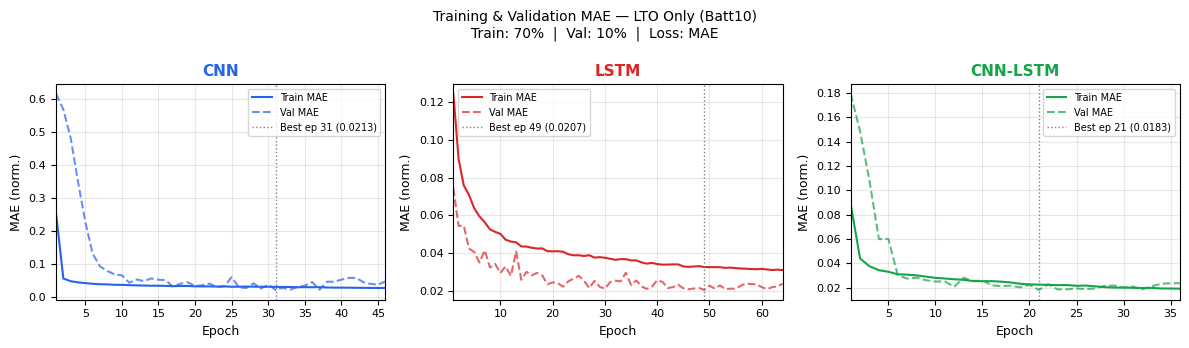

Saved → training_curves_mae.png


In [30]:
# ─── Cell 7 — Training / Validation MAE Curves  ────────────────


COLORS = {'M_CNN': '#2563EB', 'M_LSTM': '#DC2626', 'M_DUAL': '#16A34A'}
NAME_MAP = {'M_CNN': 'CNN', 'M_LSTM': 'LSTM', 'M_DUAL': 'CNN-LSTM'}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))   # thesis-sized

for ax, (name, h) in zip(axes, histories.items()):
    color   = COLORS[name]
    train_l = h.history['loss']
    val_l   = h.history['val_loss']
    epochs  = range(1, len(train_l) + 1)
    best_ep = int(np.argmin(val_l)) + 1

    ax.plot(epochs, train_l, color=color, lw=1.5, label='Train MAE')
    ax.plot(epochs, val_l,   color=color, lw=1.5, ls='--', alpha=0.7, label='Val MAE')
    ax.axvline(best_ep, color='gray', ls=':', lw=1.0,
               label=f'Best ep {best_ep} ({min(val_l):.4f})')

    display_name = NAME_MAP.get(name, name)   # clean title
    ax.set_title(display_name, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('MAE (norm.)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim(1, len(train_l))

plt.suptitle(
    'Training & Validation MAE — LTO Only (Batt10)\n'
    'Train: 70%  |  Val: 10%  |  Loss: MAE',
    fontsize=10
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'training_curves_mae.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Saved → training_curves_mae.png')

In [31]:
# ─── Cell 8 — Evaluate on LTO Test Set (Batt10 20%) ──────────────────────────

all_results = {}
all_preds   = {}
true_soc_ref = None

for name, model in trained_models.items():
    metrics, true_soc, pred_soc = evaluate(
        model, testX, testY,
        label=f'{name} — Batt10 Test (20%)')
    all_results[name] = metrics
    all_preds[name]   = (true_soc, pred_soc)
    if true_soc_ref is None:
        true_soc_ref = true_soc   # identical for all models

# Summary table
print('\n' + '='*65)
print('  SUMMARY — LTO Batt10 Test Set (20%)')
print('  Train: Batt10 70%  |  Val: Batt10 10%  |  No fine-tuning')
print('='*65)
print(f"  {'Model':<12}  {'MAE (%)':>9}  {'RMSE (%)':>9}  "
      f"{'MAPE (%)':>9}  {'Acc (%)':>8}")
print('-'*65)
for name, m in all_results.items():
    best = ' \u2190 best' if m['MAE'] == min(r['MAE'] for r in all_results.values()) else ''
    print(f"  {name:<12}  {m['MAE']:>9.4f}  {m['RMSE']:>9.4f}  "
          f"{m['MAPE']:>9.4f}  {m['Accuracy']:>8.2f}{best}")
print('='*65)


  M_CNN — Batt10 Test (20%)
  MAE      = 1.4004 % SoC
  RMSE     = 1.7382 % SoC
  MAPE     = 3.5511 %
  Accuracy = 98.60 %

  M_LSTM — Batt10 Test (20%)
  MAE      = 1.3754 % SoC
  RMSE     = 1.8604 % SoC
  MAPE     = 3.4219 %
  Accuracy = 98.62 %

  M_DUAL — Batt10 Test (20%)
  MAE      = 1.2119 % SoC
  RMSE     = 1.7536 % SoC
  MAPE     = 2.9510 %
  Accuracy = 98.79 %

  SUMMARY — LTO Batt10 Test Set (20%)
  Train: Batt10 70%  |  Val: Batt10 10%  |  No fine-tuning
  Model           MAE (%)   RMSE (%)   MAPE (%)   Acc (%)
-----------------------------------------------------------------
  M_CNN            1.4004     1.7382     3.5511     98.60
  M_LSTM           1.3754     1.8604     3.4219     98.62
  M_DUAL           1.2119     1.7536     2.9510     98.79 ← best


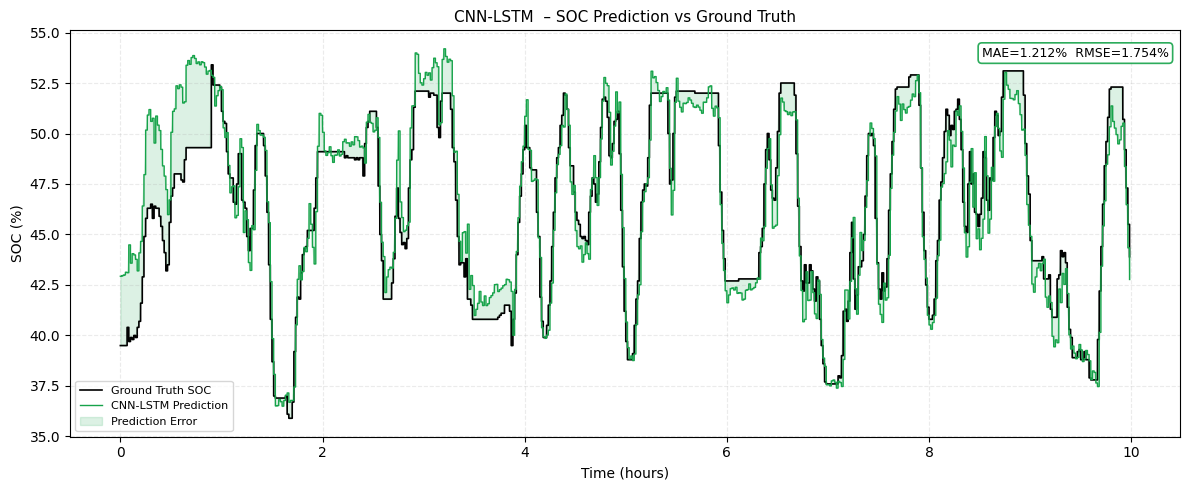

Saved → /content/figures/dual_model_predictions_10h.png


In [32]:
# ─── Cell 9b — Dual Model SOC Prediction  ─────────
WINDOW_HOURS = 10          
model_key    = 'M_DUAL'    

# Extract data
true_soc = all_preds[model_key][0]
pred_soc = all_preds[model_key][1]
mae_val  = all_results[model_key]['MAE']
rmse_val = all_results[model_key]['RMSE']
color    = COLORS.get(model_key, '#1f77b4')   

total_timesteps = len(true_soc)
window_steps    = int(WINDOW_HOURS * 60)       # each step = 1 minute
window_steps    = min(window_steps, total_timesteps)
t_hours         = np.arange(window_steps) / 60.0


true_win = true_soc[:window_steps]
pred_win = pred_soc[:window_steps]

plt.figure(figsize=(12, 5))


plt.plot(t_hours, true_win, 'k-', drawstyle='steps-post',
         lw=1.2, label='Ground Truth SOC')


plt.plot(t_hours, pred_win, color=color, drawstyle='steps-post',
         lw=1.0, label='CNN-LSTM Prediction')


plt.fill_between(t_hours, true_win, pred_win,
                 color=color, alpha=0.15, label='Prediction Error')

plt.text(0.99, 0.96,
         f'MAE={mae_val:.3f}%  RMSE={rmse_val:.3f}%',
         transform=plt.gca().transAxes, fontsize=9, ha='right', va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor=color, alpha=0.9, lw=1.2))

plt.xlabel('Time (hours)', fontsize=10)
plt.ylabel('SOC (%)', fontsize=10)
#plt.title('CNN‑LSTM' – SOC Prediction vs Ground Truth (first {WINDOW_HOURS} h)',
          #fontsize=11)
plt.title('CNN-LSTM  – SOC Prediction vs Ground Truth', fontsize=11)
plt.legend(fontsize=8)
plt.grid(alpha=0.25, ls='--')
plt.tight_layout()


save_path = os.path.join(FIG_DIR, 'dual_model_predictions_10h.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {save_path}')

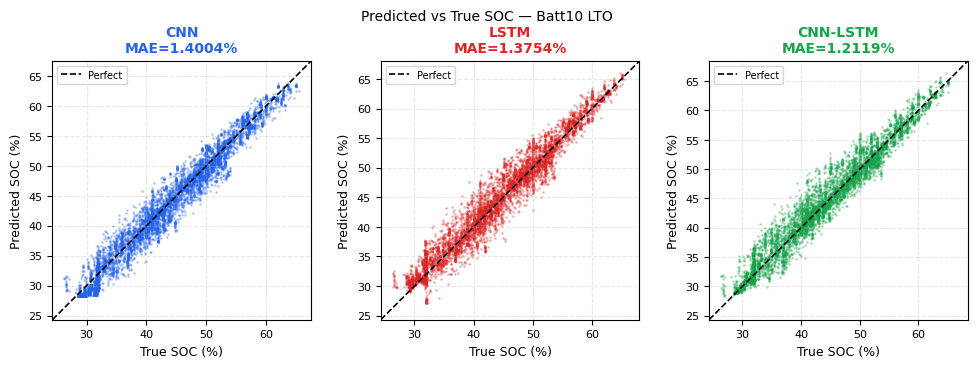

Saved → scatter_pred_vs_true.png


In [34]:
# ─── Cell 12 — Scatter: Predicted vs True SOC ─────────────────


NAME_MAP = {
    'M_CNN':  'CNN',
    'M_LSTM': 'LSTM',
    'M_DUAL': 'CNN-LSTM'       
}

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))  

for ax, (name, (true_soc, pred_soc)) in zip(axes, all_preds.items()):
    color = COLORS[name]
    ax.scatter(true_soc, pred_soc, s=1, alpha=0.25, color=color)
    lim = [min(true_soc.min(), pred_soc.min()) - 2,
           max(true_soc.max(), pred_soc.max()) + 2]
    ax.plot(lim, lim, 'k--', lw=1.2, label='Perfect')
    ax.set_xlabel('True SOC (%)', fontsize=9)
    ax.set_ylabel('Predicted SOC (%)', fontsize=9)

   
    display_name = NAME_MAP.get(name, name)   
    ax.set_title(
        f'{display_name}\n'
        f'MAE={all_results[name]["MAE"]:.4f}%',
        fontsize=10, color=color, fontweight='bold'
    )
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3, ls='--')
    ax.set_aspect('equal', 'box')

plt.suptitle('Predicted vs True SOC — Batt10 LTO ', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'scatter_pred_vs_true.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_pred_vs_true.png')

In [35]:
# ─── Cell 14 — Final Results Summary ───────────────────────────────────

print('\n' + '='*65)
print('  FINAL RESULTS — Batt10 LTO Test Set (20% holdout)')
print('  Train: Batt10 70%  |  Val: Batt10 10%')
print('  Features: V, I, V_avg_2h, I_avg_2h  |  Window: 60 min')
print('  No transfer learning  |  Loss: MAE')
print('='*65)
print(f"  {'Model':<14} {'MAE (%)':>9} {'RMSE (%)':>10} "
      f"{'MAPE (%)':>10} {'Acc (%)':>9}")
print('-'*65)
for name, m in sorted(all_results.items(),
                       key=lambda x: x[1]['MAE']):
    best = ' \u2190 best' if m['MAE'] == min(
        r['MAE'] for r in all_results.values()) else ''
    print(f"  {name:<14} {m['MAE']:>9.4f} {m['RMSE']:>10.4f} "
          f"{m['MAPE']:>10.4f} {m['Accuracy']:>9.2f}{best}")
print('='*65)


results_path = os.path.join(SAVE_DIR, 'results_lto_only.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'\n\u2713 Results saved \u2192 {results_path}')


import shutil
DRIVE_OUT = '/content/drive/MyDrive/lto_only_results'
os.makedirs(DRIVE_OUT, exist_ok=True)
for fname in os.listdir(FIG_DIR):
    shutil.copy(os.path.join(FIG_DIR, fname), DRIVE_OUT)
shutil.copy(results_path, DRIVE_OUT)
print(f'\u2713 All files saved \u2192 {DRIVE_OUT}')

print('\nFigures:')
for fname in sorted(os.listdir(FIG_DIR)):
    fp = os.path.join(FIG_DIR, fname)
    print(f'  \u2713 {fname}')


  FINAL RESULTS — Batt10 LTO Test Set (20% holdout)
  Train: Batt10 70%  |  Val: Batt10 10%
  Features: V, I, V_avg_2h, I_avg_2h  |  Window: 60 min
  No transfer learning  |  Loss: MAE
  Model            MAE (%)   RMSE (%)   MAPE (%)   Acc (%)
-----------------------------------------------------------------
  M_DUAL            1.2119     1.7536     2.9510     98.79 ← best
  M_LSTM            1.3754     1.8604     3.4219     98.62
  M_CNN             1.4004     1.7382     3.5511     98.60

✓ Results saved → /content/saved/results_lto_only.json
✓ All files saved → /content/drive/MyDrive/lto_only_results

Figures:
  ✓ dual_model_predictions_10h.png
  ✓ scatter_pred_vs_true.png
  ✓ training_curves_mae.png
